### Philip's notebook

## 1. Imports

In [4]:
import os
import shutil
import hashlib
import zipfile
from pathlib import Path

from PIL import Image
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Sequential, Input, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import efficientnet
from sklearn.model_selection import train_test_split
import keras

import matplotlib.pyplot as plt
import matplotlib as mpl

import random

from IPython.display import display
from IPython.display import Image as Image2


## Configuration

In [ ]:
# using modified version define below
# from mriproject.preproc_img import preprocess_image

In [ ]:

SEED = 42
np.random.seed(SEED)

IMG_SIZE = (224, 224)
CANONICAL_CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]


TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

################################
###    CHANGE THIS BASED ON YOUR PATH. The rest should be fine

MAIN_DIRECTORY = "." #"/Users/philipwilson/code/SimonWilliams32/MRI_project"
# MAIN_DIRECTORY = "kaggle/working/"

###

WORKING_DIR = os.path.join(MAIN_DIRECTORY, "raw_data")
PREPROCESSED_DIR = os.path.join(WORKING_DIR, "preprocessed_all_brain_tumor_images")
FINAL_DATASET_DIR = os.path.join(WORKING_DIR, "final_brain_tumor_preprocessed_dataset")
REPORT_DIR = os.path.join(WORKING_DIR, "preprocessing_reports")

os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Configuration ready.")
print("Image size:", IMG_SIZE)
print("Final dataset directory:", FINAL_DATASET_DIR)


## 2. Resolve dataset paths safely

In [70]:
RAW_DATA_DIR = os.path.join(os.getcwd(), "raw_data")

dataset_paths = {
    "Masoud": os.path.join(RAW_DATA_DIR, "brain-tumor-mri-dataset"),
    "Ishans24": os.path.join(RAW_DATA_DIR, "brain-tumor-dataset"),
    "Alamshihab075": os.path.join(RAW_DATA_DIR, "brain-tumor-mri-dataset-for-deep-learning"),
}

## 3. Class-name normalization

In [71]:
class_aliases = {
    "glioma": "glioma",
    "glioma tumor": "glioma",
    "glioma tumour": "glioma",
    "glioma_tumor": "glioma",
    "glioma-tumor": "glioma",
    "meningioma": "meningioma",
    "meningioma tumor": "meningioma",
    "meningioma tumour": "meningioma",
    "meningioma_tumor": "meningioma",
    "meningioma-tumor": "meningioma",
    "pituitary": "pituitary",
    "pituitary tumor": "pituitary",
    "pituitary tumour": "pituitary",
    "pituitary_tumor": "pituitary",
    "pituitary-tumor": "pituitary",
    "notumor": "notumor",
    "no tumor": "notumor",
    "no tumour": "notumor",
    "no_tumor": "notumor",
    "no-tumor": "notumor",
    "normal": "notumor",
    "non tumor": "notumor",
    "non_tumor": "notumor",
    "non-tumor": "notumor",
}


def normalize_text(text):
    text = str(text).lower().strip()
    text = text.replace("_", " ").replace("-", " ")
    text = " ".join(text.split())
    return text


def detect_class_from_path(path):
    for part in Path(path).parts:
        normalized = normalize_text(part)
        if normalized in class_aliases:
            return class_aliases[normalized]
    return None

## 4. Collect image paths

In [72]:
def collect_images(dataset_name, dataset_path):
    rows = []
    skipped_unknown_class = 0

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if not file.lower().endswith(IMAGE_EXTS):
                continue

            image_path = os.path.join(root, file)
            detected_class = detect_class_from_path(image_path)

            if detected_class is None:
                skipped_unknown_class += 1
                continue

            rows.append({
                "Dataset": dataset_name,
                "Original Path": image_path,
                "Class": detected_class,
                "Original Filename": file,
                "Original Relative Path": os.path.relpath(image_path, dataset_path),
                "Original Folder": os.path.relpath(root, dataset_path),
                "Original Extension": Path(file).suffix.lower(),
            })

    return rows, skipped_unknown_class


all_rows = []
skipped_summary = []

for dataset_name, dataset_path in dataset_paths.items():
    rows, skipped = collect_images(dataset_name, dataset_path)
    print(f"{dataset_name}: found {len(rows)} class-detected images; skipped {skipped} unknown-class images.")
    all_rows.extend(rows)
    skipped_summary.append({
        "Dataset": dataset_name,
        "Detected Images": len(rows),
        "Skipped Unknown Class": skipped,
    })

raw_df = pd.DataFrame(all_rows)

if raw_df.empty:
    raise ValueError("No images were detected. Check folder structure and class mappings.")

display(pd.DataFrame(skipped_summary))
print("Total detected images:", len(raw_df))
display(raw_df.head())

raw_counts = (
    raw_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Raw Image Count")
    .sort_values(["Dataset", "Class"])
)

display(raw_counts)

raw_df.to_csv(os.path.join(REPORT_DIR, "01_raw_detected_images.csv"), index=False)
raw_counts.to_csv(os.path.join(REPORT_DIR, "02_raw_class_counts.csv"), index=False)

Masoud: found 7200 class-detected images; skipped 0 unknown-class images.
Ishans24: found 10560 class-detected images; skipped 0 unknown-class images.
Alamshihab075: found 9257 class-detected images; skipped 0 unknown-class images.


,Dataset,Detected Images,Skipped Unknown Class
0,Masoud,7200,0
1,Ishans24,10560,0
2,Alamshihab075,9257,0


Total detected images: 27017


,Dataset,Original Path,Class,Original Filename,Original Relative Path,Original Folder,Original Extension
0,Masoud,/Users/philipwilson/code/SimonWilliams32/MRI_p...,pituitary,Tr-pi_766.jpg,Training/pituitary/Tr-pi_766.jpg,Training/pituitary,.jpg
1,Masoud,/Users/philipwilson/code/SimonWilliams32/MRI_p...,pituitary,Tr-pi_1169.jpg,Training/pituitary/Tr-pi_1169.jpg,Training/pituitary,.jpg
2,Masoud,/Users/philipwilson/code/SimonWilliams32/MRI_p...,pituitary,Tr-pi_772.jpg,Training/pituitary/Tr-pi_772.jpg,Training/pituitary,.jpg
3,Masoud,/Users/philipwilson/code/SimonWilliams32/MRI_p...,pituitary,Tr-pi_982.jpg,Training/pituitary/Tr-pi_982.jpg,Training/pituitary,.jpg
4,Masoud,/Users/philipwilson/code/SimonWilliams32/MRI_p...,pituitary,Tr-pi_1141.jpg,Training/pituitary/Tr-pi_1141.jpg,Training/pituitary,.jpg


,Dataset,Class,Raw Image Count
0,Alamshihab075,glioma,3293
1,Alamshihab075,meningioma,3593
2,Alamshihab075,notumor,811
3,Alamshihab075,pituitary,1560
4,Ishans24,glioma,3754
5,Ishans24,meningioma,2343
6,Ishans24,notumor,1757
7,Ishans24,pituitary,2706
8,Masoud,glioma,1800
9,Masoud,meningioma,1800


## 5. Show raw samples

In [73]:
'''
def show_raw_samples(dataset_name, n=8):
    temp_df = raw_df[raw_df["Dataset"] == dataset_name]
    if temp_df.empty:
        print("No images for", dataset_name)
        return

    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)
    plt.figure(figsize=(14, 6))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        try:
            img = Image.open(row["Original Path"])
            plt.subplot(2, 4, i + 1)
            plt.imshow(img, cmap="gray")
            plt.title(f"{row['Class']}\n{img.size[0]}x{img.size[1]} {img.mode}")
            plt.axis("off")
        except Exception as e:
            print("Could not open:", row["Original Path"], e)

    plt.suptitle(f"Raw samples - {dataset_name}")
    plt.tight_layout()
    plt.show()


for name in dataset_paths.keys():
    show_raw_samples(name, n=8)
'''

'\ndef show_raw_samples(dataset_name, n=8):\n    temp_df = raw_df[raw_df["Dataset"] == dataset_name]\n    if temp_df.empty:\n        print("No images for", dataset_name)\n        return\n\n    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)\n    plt.figure(figsize=(14, 6))\n\n    for i, (_, row) in enumerate(sample_df.iterrows()):\n        try:\n            img = Image.open(row["Original Path"])\n            plt.subplot(2, 4, i + 1)\n            plt.imshow(img, cmap="gray")\n            plt.title(f"{row[\'Class\']}\n{img.size[0]}x{img.size[1]} {img.mode}")\n            plt.axis("off")\n        except Exception as e:\n            print("Could not open:", row["Original Path"], e)\n\n    plt.suptitle(f"Raw samples - {dataset_name}")\n    plt.tight_layout()\n    plt.show()\n\n\nfor name in dataset_paths.keys():\n    show_raw_samples(name, n=8)\n'

## 6. Preprocess every image and hash preprocessed pixels

In [74]:
def reset_directory(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


# Reset preprocessing output to avoid mixing old and new runs.
reset_directory(PREPROCESSED_DIR)

try:
    RESAMPLE_FILTER = Image.Resampling.LANCZOS
except AttributeError:
    RESAMPLE_FILTER = Image.LANCZOS


def preprocess_image(image_path, img_size=IMG_SIZE):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize(img_size, RESAMPLE_FILTER)
    return img


def hash_preprocessed_image(img):
    arr = np.asarray(img)
    return hashlib.md5(arr.tobytes()).hexdigest()


processed_rows = []
failed_rows = []

total_images = len(raw_df)
for idx, row in raw_df.reset_index(drop=True).iterrows():
    dataset_name = row["Dataset"]
    class_name = row["Class"]
    original_path = row["Original Path"]

    try:
        img = preprocess_image(original_path, img_size=IMG_SIZE)
        img_hash = hash_preprocessed_image(img)

        save_dir = os.path.join(PREPROCESSED_DIR, dataset_name, class_name)
        os.makedirs(save_dir, exist_ok=True)

        save_filename = f"{dataset_name}_{idx:06d}_{img_hash}.png"
        save_path = os.path.join(save_dir, save_filename)
        img.save(save_path, format="PNG")

        processed_rows.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Original Path": original_path,
            "Original Relative Path": row["Original Relative Path"],
            "Processed Path": save_path,
            "Preprocessed Hash": img_hash,
            "Width": IMG_SIZE[0],
            "Height": IMG_SIZE[1],
            "Mode": "RGB",
        })
    except Exception as e:
        failed_rows.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Original Path": original_path,
            "Error": str(e),
        })

    if (idx + 1) % 2000 == 0 or (idx + 1) == total_images:
        print(f"Processed {idx + 1}/{total_images} images...")

processed_df = pd.DataFrame(processed_rows)
failed_df = pd.DataFrame(failed_rows)

if processed_df.empty:
    raise ValueError("All preprocessing failed; no processed images were created.")

print("Total preprocessed images:", len(processed_df))
print("Failed images:", len(failed_df))

display(processed_df.head())

processed_counts = (
    processed_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Preprocessed Count")
    .sort_values(["Dataset", "Class"])
)

display(processed_counts)

processed_df.to_csv(os.path.join(REPORT_DIR, "03_preprocessed_images.csv"), index=False)
processed_counts.to_csv(os.path.join(REPORT_DIR, "04_preprocessed_class_counts.csv"), index=False)
failed_df.to_csv(os.path.join(REPORT_DIR, "05_failed_preprocessing.csv"), index=False)

Processed 2000/27017 images...
Processed 4000/27017 images...
Processed 6000/27017 images...
Processed 8000/27017 images...
Processed 10000/27017 images...
Processed 12000/27017 images...
Processed 14000/27017 images...
Processed 16000/27017 images...
Processed 18000/27017 images...
Processed 20000/27017 images...
Processed 22000/27017 images...
Processed 24000/27017 images...
Processed 26000/27017 images...
Processed 27017/27017 images...
Total preprocessed images: 27017
Failed images: 0


,Dataset,Class,Original Path,Original Relative Path,Processed Path,Preprocessed Hash,Width,Height,Mode
0,Masoud,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Training/pituitary/Tr-pi_766.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,b6fdb0a513678645b28bff819834fe27,224,224,RGB
1,Masoud,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Training/pituitary/Tr-pi_1169.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,c75ab73798ef17c4a6d2b9d437bcb19c,224,224,RGB
2,Masoud,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Training/pituitary/Tr-pi_772.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,e048877a2d0d08777a9f141686204cd0,224,224,RGB
3,Masoud,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Training/pituitary/Tr-pi_982.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,2dec1b7388f31da609e7fa2ab765a4e3,224,224,RGB
4,Masoud,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Training/pituitary/Tr-pi_1141.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,a74e542bd81af066060adabf2ca06a1f,224,224,RGB


,Dataset,Class,Preprocessed Count
0,Alamshihab075,glioma,3293
1,Alamshihab075,meningioma,3593
2,Alamshihab075,notumor,811
3,Alamshihab075,pituitary,1560
4,Ishans24,glioma,3754
5,Ishans24,meningioma,2343
6,Ishans24,notumor,1757
7,Ishans24,pituitary,2706
8,Masoud,glioma,1800
9,Masoud,meningioma,1800


## 7. Find duplicates after preprocessing

In [75]:
duplicate_df = (
    processed_df.groupby("Preprocessed Hash")
    .filter(lambda x: len(x) > 1)
    .sort_values(["Preprocessed Hash", "Dataset", "Class"])
    .reset_index(drop=True)
)

if duplicate_df.empty:
    duplicate_hash_summary_df = pd.DataFrame(columns=[
        "Preprocessed Hash", "Duplicate_Entries", "Number_of_Datasets", "Classes", "Datasets"
    ])
    cross_dataset_duplicate_hashes_df = duplicate_hash_summary_df.copy()
else:
    duplicate_hash_summary_df = (
        duplicate_df.groupby("Preprocessed Hash")
        .agg(
            Duplicate_Entries=("Preprocessed Hash", "size"),
            Number_of_Datasets=("Dataset", "nunique"),
            Classes=("Class", lambda x: ", ".join(sorted(set(x)))),
            Datasets=("Dataset", lambda x: ", ".join(sorted(set(x)))),
        )
        .reset_index()
        .sort_values(["Number_of_Datasets", "Duplicate_Entries"], ascending=False)
    )

    cross_dataset_duplicate_hashes_df = duplicate_hash_summary_df[
        duplicate_hash_summary_df["Number_of_Datasets"] > 1
    ].copy()

print("Duplicate image entries after preprocessing:", len(duplicate_df))
print("Duplicate hash groups:", duplicate_df["Preprocessed Hash"].nunique() if not duplicate_df.empty else 0)
print("Duplicate hash groups appearing in more than one dataset:", len(cross_dataset_duplicate_hashes_df))

display(duplicate_df.head(100))
display(cross_dataset_duplicate_hashes_df.head(100))

duplicate_df.to_csv(os.path.join(REPORT_DIR, "06_duplicate_entries_after_preprocessing.csv"), index=False)
duplicate_hash_summary_df.to_csv(os.path.join(REPORT_DIR, "07_duplicate_hash_summary.csv"), index=False)
cross_dataset_duplicate_hashes_df.to_csv(os.path.join(REPORT_DIR, "08_cross_dataset_duplicate_hashes.csv"), index=False)

Duplicate image entries after preprocessing: 19590
Duplicate hash groups: 7175
Duplicate hash groups appearing in more than one dataset: 7175


,Dataset,Class,Original Path,Original Relative Path,Processed Path,Preprocessed Hash,Width,Height,Mode
0,Alamshihab075,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,test/test/Pituitary/images/Tr-pi_0532.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,000296ed3f14282e340765e5d7b24227,224,224,RGB
1,Alamshihab075,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Train/Train/Pituitary/images/p (584).jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,000296ed3f14282e340765e5d7b24227,224,224,RGB
2,Ishans24,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,pituitary/pituitary1165.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,000296ed3f14282e340765e5d7b24227,224,224,RGB
3,Masoud,pituitary,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Training/pituitary/Tr-pi_24.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,000296ed3f14282e340765e5d7b24227,224,224,RGB
4,Alamshihab075,meningioma,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Train/Train/Meningioma/images/m2 (22).jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,0004a762d764396f8f5518caf1640432,224,224,RGB
...,...,...,...,...,...,...,...,...,...
95,Ishans24,meningioma,/Users/philipwilson/code/SimonWilliams32/MRI_p...,meningioma/meningioma827.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,011681873205e53c70e8c730e3fa64e4,224,224,RGB
96,Masoud,meningioma,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Training/meningioma/Tr-me_1133.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,011681873205e53c70e8c730e3fa64e4,224,224,RGB
97,Alamshihab075,meningioma,/Users/philipwilson/code/SimonWilliams32/MRI_p...,Train/Train/Meningioma/images/m2 (55).jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,011b482b57166bb39b8c42911eeb46e2,224,224,RGB
98,Ishans24,meningioma,/Users/philipwilson/code/SimonWilliams32/MRI_p...,meningioma/meningioma1065.jpg,/Users/philipwilson/code/SimonWilliams32/MRI_p...,011b482b57166bb39b8c42911eeb46e2,224,224,RGB


,Preprocessed Hash,Duplicate_Entries,Number_of_Datasets,Classes,Datasets
2082,4948cd41e195a81192b2c160952197ee,16,3,notumor,"Alamshihab075, Ishans24, Masoud"
1216,2ae817c198efa08837133cb845fd29b0,13,3,meningioma,"Alamshihab075, Ishans24, Masoud"
518,1210952b4e54f23ce1450e6c04f01211,12,3,notumor,"Alamshihab075, Ishans24, Masoud"
1473,344396fa3b3359533286e8bd1cd22bce,11,3,notumor,"Alamshihab075, Ishans24, Masoud"
2448,55caee96126e665a1b54070e234359a0,11,3,notumor,"Alamshihab075, Ishans24, Masoud"
...,...,...,...,...,...
5716,ca2fa9b233e253611aafd605053cb9b6,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
5864,cf5761e4ba32866383a43edb2a571647,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
6080,d71bf2b41416468598fb73cb26909c79,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
6188,db306467e793f4e4474e0f313370ec21,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"


## 8. Deduplicate Masoud + Ishans24 for internal train/validation/test

In [76]:
internal_sources = ["Masoud", "Ishans24"]
internal_df = processed_df[processed_df["Dataset"].isin(internal_sources)].copy()

if internal_df.empty:
    raise ValueError("Internal pool is empty. Masoud and Ishans24 images were not found.")

source_priority = {"Masoud": 0, "Ishans24": 1}
internal_df["Source Priority"] = internal_df["Dataset"].map(source_priority)

internal_dedup_df = (
    internal_df.sort_values(["Preprocessed Hash", "Source Priority", "Dataset"])
    .drop_duplicates(subset=["Preprocessed Hash"], keep="first")
    .reset_index(drop=True)
)

print("Internal source images before deduplication:", len(internal_df))
print("Internal source images after deduplication:", len(internal_dedup_df))
print("Removed internal duplicates:", len(internal_df) - len(internal_dedup_df))

internal_dataset_class_counts = (
    internal_dedup_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Dataset", "Class"])
)
internal_class_counts = (
    internal_dedup_df.groupby("Class")
    .size()
    .reset_index(name="Count")
    .sort_values("Class")
)

display(internal_dataset_class_counts)
display(internal_class_counts)

internal_dedup_df.to_csv(os.path.join(REPORT_DIR, "09_internal_masoud_ishans24_deduplicated.csv"), index=False)
internal_class_counts.to_csv(os.path.join(REPORT_DIR, "10_internal_deduplicated_class_counts.csv"), index=False)

Internal source images before deduplication: 17760
Internal source images after deduplication: 10594
Removed internal duplicates: 7166


,Dataset,Class,Count
0,Ishans24,glioma,1959
1,Ishans24,meningioma,746
2,Ishans24,notumor,75
3,Ishans24,pituitary,936
4,Masoud,glioma,1779
5,Masoud,meningioma,1684
6,Masoud,notumor,1657
7,Masoud,pituitary,1758


,Class,Count
0,glioma,3738
1,meningioma,2430
2,notumor,1732
3,pituitary,2694


## 9. Deduplicate Alamshihab075 for external validation

In [77]:
alam_df = processed_df[processed_df["Dataset"] == "Alamshihab075"].copy()

if alam_df.empty:
    print("WARNING: Alamshihab075 pool is empty. External validation will be empty.")
    external_dedup_df = alam_df.copy()
else:
    internal_hashes = set(internal_dedup_df["Preprocessed Hash"])

    # Remove duplicates inside Alamshihab075 first.
    alam_unique_df = (
        alam_df.drop_duplicates(subset=["Preprocessed Hash"], keep="first")
        .reset_index(drop=True)
    )

    # Remove any Alamshihab075 image that appears in the internal pool.
    external_dedup_df = alam_unique_df[
        ~alam_unique_df["Preprocessed Hash"].isin(internal_hashes)
    ].reset_index(drop=True)

    print("Alamshihab075 original preprocessed images:", len(alam_df))
    print("Alamshihab075 unique images:", len(alam_unique_df))
    print("Final external validation images:", len(external_dedup_df))
    print("Removed Alamshihab075 images duplicated with internal pool:", len(alam_unique_df) - len(external_dedup_df))

external_class_counts = (
    external_dedup_df.groupby("Class")
    .size()
    .reset_index(name="External Validation Count")
    .sort_values("Class")
)

display(external_class_counts)

external_dedup_df.to_csv(os.path.join(REPORT_DIR, "11_external_alamshihab075_deduplicated.csv"), index=False)
external_class_counts.to_csv(os.path.join(REPORT_DIR, "12_external_deduplicated_class_counts.csv"), index=False)

Alamshihab075 original preprocessed images: 9257
Alamshihab075 unique images: 7914
Final external validation images: 4008
Removed Alamshihab075 images duplicated with internal pool: 3906


,Class,External Validation Count
0,glioma,2004
1,meningioma,2004


## 10. Stratified split: train / validation / internal test

In [78]:
if len(internal_dedup_df) == 0:
    raise ValueError("Internal deduplicated dataset is empty.")

class_counts = internal_dedup_df["Class"].value_counts()
print("Internal class counts before split:")
display(class_counts.to_frame("Count"))

if (class_counts < 3).any():
    raise ValueError("At least one class has fewer than 3 images, so stratified splitting is unsafe.")

train_val_df, internal_test_df = train_test_split(
    internal_dedup_df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=internal_dedup_df["Class"],
)

val_adjusted_ratio = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_adjusted_ratio,
    random_state=SEED,
    stratify=train_val_df["Class"],
)

split_summary_rows = []
for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", internal_test_df),
    ("external_val", external_dedup_df),
]:
    for class_name in CANONICAL_CLASSES:
        count = int((df["Class"] == class_name).sum()) if not df.empty else 0
        split_summary_rows.append({"Split": split_name, "Class": class_name, "Count": count})

split_summary_df = pd.DataFrame(split_summary_rows)

print("Split sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Internal test:", len(internal_test_df))
print("External validation:", len(external_dedup_df))

display(split_summary_df)

train_df.to_csv(os.path.join(REPORT_DIR, "13_train_split.csv"), index=False)
val_df.to_csv(os.path.join(REPORT_DIR, "14_val_split.csv"), index=False)
internal_test_df.to_csv(os.path.join(REPORT_DIR, "15_internal_test_split.csv"), index=False)
split_summary_df.to_csv(os.path.join(REPORT_DIR, "16_final_split_class_counts.csv"), index=False)

Internal class counts before split:


,Count
Class,
glioma,3738
pituitary,2694
meningioma,2430
notumor,1732


Split sizes:
Train: 7415
Validation: 1589
Internal test: 1590
External validation: 4008


,Split,Class,Count
0,train,glioma,2616
1,train,meningioma,1701
2,train,notumor,1212
3,train,pituitary,1886
4,val,glioma,561
5,val,meningioma,364
6,val,notumor,260
7,val,pituitary,404
8,test,glioma,561
9,test,meningioma,365


## 11. Create final folder dataset

In [79]:
reset_directory(FINAL_DATASET_DIR)

for split_name in ["train", "val", "test", "external_val"]:
    for class_name in CANONICAL_CLASSES:
        os.makedirs(os.path.join(FINAL_DATASET_DIR, split_name, class_name), exist_ok=True)


def copy_split_images(df, split_name):
    copied_rows = []
    if df.empty:
        return copied_rows

    for i, row in df.reset_index(drop=True).iterrows():
        src = row["Processed Path"]
        class_name = row["Class"]
        img_hash = row["Preprocessed Hash"]
        dataset_name = row["Dataset"]

        dst_filename = f"{split_name}_{dataset_name}_{i:06d}_{img_hash}.png"
        dst = os.path.join(FINAL_DATASET_DIR, split_name, class_name, dst_filename)
        shutil.copy2(src, dst)

        copied_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Dataset": dataset_name,
            "Source Processed Path": src,
            "Final Path": dst,
            "Preprocessed Hash": img_hash,
        })

    return copied_rows


final_copy_rows = []
final_copy_rows.extend(copy_split_images(train_df, "train"))
final_copy_rows.extend(copy_split_images(val_df, "val"))
final_copy_rows.extend(copy_split_images(internal_test_df, "test"))
final_copy_rows.extend(copy_split_images(external_dedup_df, "external_val"))

final_manifest_df = pd.DataFrame(final_copy_rows)

print("Final dataset created at:")
print(FINAL_DATASET_DIR)
display(final_manifest_df.head())

final_manifest_df.to_csv(os.path.join(REPORT_DIR, "17_final_dataset_manifest.csv"), index=False)

Final dataset created at:
/Users/philipwilson/code/SimonWilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset


,Split,Class,Dataset,Source Processed Path,Final Path,Preprocessed Hash
0,train,pituitary,Ishans24,/Users/philipwilson/code/SimonWilliams32/MRI_p...,/Users/philipwilson/code/SimonWilliams32/MRI_p...,1bb15d9a62ae98791b06f7745858a356
1,train,glioma,Masoud,/Users/philipwilson/code/SimonWilliams32/MRI_p...,/Users/philipwilson/code/SimonWilliams32/MRI_p...,1a18ef2b22044027a686ff45afb8caa5
2,train,meningioma,Masoud,/Users/philipwilson/code/SimonWilliams32/MRI_p...,/Users/philipwilson/code/SimonWilliams32/MRI_p...,414b0db119dcc6a7f3d88bd9e7683f49
3,train,pituitary,Ishans24,/Users/philipwilson/code/SimonWilliams32/MRI_p...,/Users/philipwilson/code/SimonWilliams32/MRI_p...,2f37397f374e82235b8467e971d2e239
4,train,pituitary,Masoud,/Users/philipwilson/code/SimonWilliams32/MRI_p...,/Users/philipwilson/code/SimonWilliams32/MRI_p...,ae459f0c67e6e2a3d8a3d77cb97dc6ae


## 12. Verify final dataset and check duplicate leakage

In [80]:
def collect_final_images(final_dir):
    rows = []
    for split_name in ["train", "val", "test", "external_val"]:
        for class_name in CANONICAL_CLASSES:
            class_dir = os.path.join(final_dir, split_name, class_name)
            if not os.path.exists(class_dir):
                continue

            for file in os.listdir(class_dir):
                if not file.lower().endswith(".png"):
                    continue

                path = os.path.join(class_dir, file)
                try:
                    img = preprocess_image(path, img_size=IMG_SIZE)
                    img_hash = hash_preprocessed_image(img)
                except Exception as e:
                    print("Could not hash final image:", path, e)
                    img_hash = None

                rows.append({
                    "Split": split_name,
                    "Class": class_name,
                    "Path": path,
                    "Filename": file,
                    "Hash": img_hash,
                })
    return pd.DataFrame(rows)


final_check_df = collect_final_images(FINAL_DATASET_DIR)

print("Final total images:", len(final_check_df))

final_counts_df = (
    final_check_df.groupby(["Split", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Split", "Class"])
)

display(final_counts_df)

if final_check_df.empty:
    leakage_df = pd.DataFrame(columns=final_check_df.columns)
    within_split_duplicate_df = pd.DataFrame(columns=final_check_df.columns)
else:
    leakage_df = (
        final_check_df.groupby("Hash")
        .filter(lambda x: x["Split"].nunique() > 1)
        .sort_values(["Hash", "Split"])
        .reset_index(drop=True)
    )

    within_split_duplicate_df = (
        final_check_df.groupby(["Split", "Hash"])
        .filter(lambda x: len(x) > 1)
        .sort_values(["Split", "Hash"])
        .reset_index(drop=True)
    )

print("Duplicate leakage across train/val/test/external_val:", len(leakage_df))
if len(leakage_df) > 0:
    print("WARNING: Duplicate leakage found across splits.")
    display(leakage_df.head(100))
else:
    print("Good: no duplicate images across final splits.")

print("Duplicate entries within the same split:", len(within_split_duplicate_df))
if len(within_split_duplicate_df) > 0:
    display(within_split_duplicate_df.head(100))
else:
    print("Good: no duplicate entries within individual splits.")

final_check_df.to_csv(os.path.join(REPORT_DIR, "18_final_dataset_check.csv"), index=False)
final_counts_df.to_csv(os.path.join(REPORT_DIR, "19_final_dataset_counts.csv"), index=False)
leakage_df.to_csv(os.path.join(REPORT_DIR, "20_final_split_leakage_check.csv"), index=False)
within_split_duplicate_df.to_csv(os.path.join(REPORT_DIR, "21_final_within_split_duplicate_check.csv"), index=False)

Final total images: 14602


,Split,Class,Count
0,external_val,glioma,2004
1,external_val,meningioma,2004
2,test,glioma,561
3,test,meningioma,365
4,test,notumor,260
5,test,pituitary,404
6,train,glioma,2616
7,train,meningioma,1701
8,train,notumor,1212
9,train,pituitary,1886


Duplicate leakage across train/val/test/external_val: 0
Good: no duplicate images across final splits.
Duplicate entries within the same split: 0
Good: no duplicate entries within individual splits.


In [91]:
{'shape': (1,124, 124,1)}

{'shape': (1, 124, 124, 1)}

## 13. Plot final class distributions

In [81]:
'''
for split_name in ["train", "val", "test", "external_val"]:
    temp_df = final_counts_df[final_counts_df["Split"] == split_name]
    plt.figure(figsize=(7, 4))
    plt.bar(temp_df["Class"], temp_df["Count"])
    plt.title(f"Class distribution - {split_name}")
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
'''

'\nfor split_name in ["train", "val", "test", "external_val"]:\n    temp_df = final_counts_df[final_counts_df["Split"] == split_name]\n    plt.figure(figsize=(7, 4))\n    plt.bar(temp_df["Class"], temp_df["Count"])\n    plt.title(f"Class distribution - {split_name}")\n    plt.xlabel("Class")\n    plt.ylabel("Number of images")\n    plt.xticks(rotation=30, ha="right")\n    plt.tight_layout()\n    plt.show()\n'

## 14. Show final sample images

In [82]:
'''
def show_final_samples(split_name, n=8):
    temp_df = final_check_df[final_check_df["Split"] == split_name]
    if temp_df.empty:
        print("No images for split:", split_name)
        return

    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)
    plt.figure(figsize=(14, 6))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["Path"])
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{row['Split']} / {row['Class']}")
        plt.axis("off")

    plt.suptitle(f"Final samples - {split_name}")
    plt.tight_layout()
    plt.show()


for split_name in ["train", "val", "test", "external_val"]:
    show_final_samples(split_name, n=8)
'''

'\ndef show_final_samples(split_name, n=8):\n    temp_df = final_check_df[final_check_df["Split"] == split_name]\n    if temp_df.empty:\n        print("No images for split:", split_name)\n        return\n\n    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)\n    plt.figure(figsize=(14, 6))\n\n    for i, (_, row) in enumerate(sample_df.iterrows()):\n        img = Image.open(row["Path"])\n        plt.subplot(2, 4, i + 1)\n        plt.imshow(img)\n        plt.title(f"{row[\'Split\']} / {row[\'Class\']}")\n        plt.axis("off")\n\n    plt.suptitle(f"Final samples - {split_name}")\n    plt.tight_layout()\n    plt.show()\n\n\nfor split_name in ["train", "val", "test", "external_val"]:\n    show_final_samples(split_name, n=8)\n'

## 16. Use this output in your training notebook

In [83]:
#FINAL_DATASET_DIR = "/Users/philipwilson/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset"

TRAIN_DIR = FINAL_DATASET_DIR + "/train"
VAL_DIR = FINAL_DATASET_DIR + "/val"
TEST_DIR = FINAL_DATASET_DIR + "/test"
EXTERNAL_VAL_DIR = FINAL_DATASET_DIR + "/external_val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_names = ["glioma", "meningioma", "notumor", "pituitary"]
notumor_index = class_names.index("notumor") # index 2

import tensorflow as tf
train_ds = tf.keras.utils.image_dataset_from_directory(
     TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode="grayscale",
     label_mode="categorical", shuffle=True, class_names=class_names
 )
val_ds = tf.keras.utils.image_dataset_from_directory(
     VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode="grayscale",
     label_mode="categorical", shuffle=False, class_names=class_names
 )
test_ds = tf.keras.utils.image_dataset_from_directory(
     TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode="grayscale",
     label_mode="categorical", shuffle=False, class_names=class_names
 )
external_val_ds = tf.keras.utils.image_dataset_from_directory(
     EXTERNAL_VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode="grayscale",
     label_mode="categorical", shuffle=False, class_names=class_names
 )
#AUTOTUNE = tf.data.AUTOTUNE
#train_ds = train_ds.prefetch(AUTOTUNE)
#val_ds = val_ds.prefetch(AUTOTUNE)
#test_ds = test_ds.prefetch(AUTOTUNE)
#external_val_ds = external_val_ds.prefetch(AUTOTUNE)

print("Training paths prepared:")
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("EXTERNAL_VAL_DIR:", EXTERNAL_VAL_DIR)

Found 7415 files belonging to 4 classes.
Found 1589 files belonging to 4 classes.
Found 1590 files belonging to 4 classes.
Found 4008 files belonging to 4 classes.
Training paths prepared:
TRAIN_DIR: /Users/philipwilson/code/SimonWilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/train
VAL_DIR: /Users/philipwilson/code/SimonWilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/val
TEST_DIR: /Users/philipwilson/code/SimonWilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/test
EXTERNAL_VAL_DIR: /Users/philipwilson/code/SimonWilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/external_val


## 17. Scaling


In [84]:
#Inspect Shape
images, labels = next(iter(train_ds))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print("\nFirst image shape:", images[0].shape)
print("First label:", labels[0])

#Next block
#check pixel values
for images, labels in train_ds.take(5):
    print(images.numpy().min(),
          images.numpy().max())

#Next block
#Scale down pixel values
train_ds_scaled = train_ds.map(lambda images, labels: (images / 255.0, labels))
val_ds_scaled = val_ds.map(lambda images, labels: (images / 255.0, labels))
test_ds_scaled = test_ds.map(lambda images, labels: (images / 255.0, labels))
external_val_ds_scaled = external_val_ds.map(lambda images, labels: (images / 255.0, labels))

#Next block
#Check that scaling has been done (shouls be between 0 and 1)
images, labels = next(iter(train_ds_scaled))
print(images.numpy().min())
print(images.numpy().max())
print(images.dtype)

Images shape: (32, 224, 224, 1)
Labels shape: (32, 4)
Image dtype: <dtype: 'float32'>

First image shape: (224, 224, 1)
First label: tf.Tensor([0. 0. 1. 0.], shape=(4,), dtype=float32)
0.0 255.0
0.0 255.0
0.0 255.0
0.0 255.0
0.0 255.0
0.0
1.0
<dtype: 'float32'>


## 18. Check dimension

In [85]:
images, labels = next(iter(train_ds_scaled))
print("Shape after grayscale conversion:", images.shape)  # expect (32, 224, 224, 1)

Shape after grayscale conversion: (32, 224, 224, 1)


## 19. Autotuning (inactive)

In [86]:
# this was part of the already available preprocessing pipeline
# it increasing efficieny

#AUTOTUNE = tf.data.AUTOTUNE

#train_ds_scaled = train_ds_scaled.prefetch(AUTOTUNE)
#val_ds_scaled = val_ds_scaled.prefetch(AUTOTUNE)
#test_ds_scaled = test_ds_scaled.prefetch(AUTOTUNE)
#external_val_ds_scaled = external_val_ds_scaled.prefetch(AUTOTUNE)

## 19. Convert to binary

In [87]:
def to_binary_label(images, labels):
    # first, find the index where the label encoding is 1
    class_idx = tf.argmax(labels, axis=1)
    # if this index equals to the notumor_index, label as healthy, otherwise cancer
    # healthy (notumor) = 0, everything else (cancer) = 1
    binary_label = tf.cast(tf.not_equal(class_idx, notumor_index), tf.float32)
    binary_label = tf.expand_dims(binary_label, axis=1)  # shape (batch, 1) for binary_crossentropy
    return images, binary_label

train_ds_binary = train_ds_scaled.map(to_binary_label)
val_ds_binary = val_ds_scaled.map(to_binary_label)
test_ds_binary = test_ds_scaled.map(to_binary_label)
external_val_ds_binary = external_val_ds_scaled.map(to_binary_label)

## 20. Start modelling

## Model 2

In [3]:
model2 = Sequential()
model2.add(Input(shape=(224, 224, 1)))
# 5 layers
model2.add(layers.Conv2D(16, (2, 2), activation="relu"))
model2.add(layers.MaxPool2D(pool_size=(2, 2)))
model2.add(layers.Conv2D(16, (2, 2), activation="relu"))
model2.add(layers.MaxPool2D(pool_size=(2, 2)))
model2.add(layers.Conv2D(16, (2, 2), activation="relu"))
model2.add(layers.MaxPool2D(pool_size=(2, 2)))
model2.add(layers.Conv2D(16, (2, 2), activation="relu"))
model2.add(layers.MaxPool2D(pool_size=(2, 2)))
model2.add(layers.Conv2D(16, (2, 2), activation="relu"))
model2.add(layers.MaxPool2D(pool_size=(2, 2)))

model2.add(layers.Flatten())
model2.add(layers.Dense(6, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 223, 223, 16)   │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 110, 110, 16)   │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 54, 54, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 27, 27, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         3,462 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,709 (30.11 KB)

 Trainable params: 7,709 (30.11 KB)

 Non-trainable params: 0 (0.00 B)

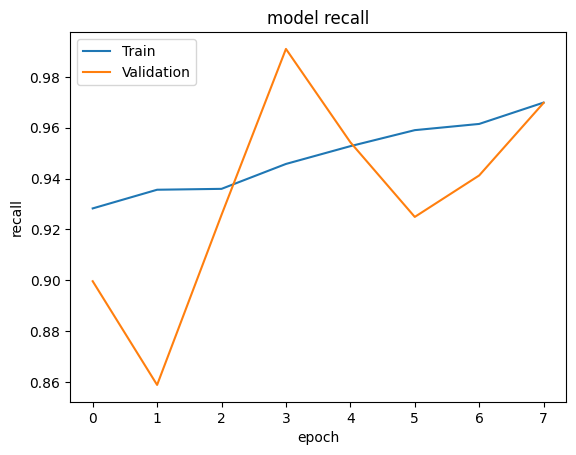

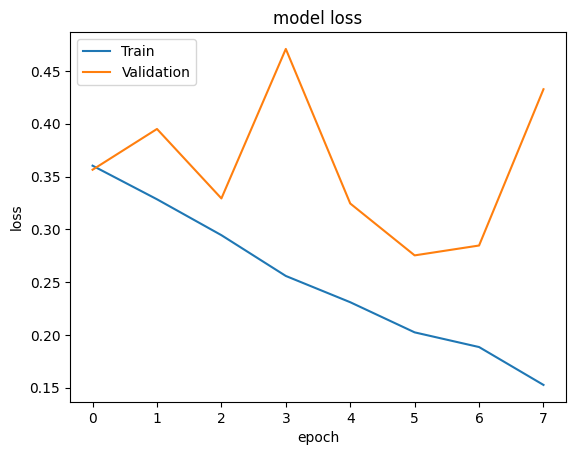

In [ ]:
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# XAI

### Function to select a random image from the test folder of the chosen class

In [50]:

def get_random_external_test_img(class_name="glioma", rand_seed = None, display=False):
    random.seed(rand_seed)
    chosen_type_folder =  os.path.join("raw_data/final_brain_tumor_preprocessed_dataset/test", class_name)
    filenames = os.listdir(chosen_type_folder)
    random_filename = "".join([chosen_type_folder, "/", random.choice(filenames)])

    img = Image.open(random_filename)
    if display==True:
        img.show()
    return (img, random_filename)


### Function to scale image, convert to array, scale if chosen, convert to greyscale if chosen, add dimension for batch size of 1

In [9]:
def preprocess_image(img, scale=False, rgb=False):
    """
    this function is used for the processing of the image provided by the user
    """

    #img = Image.open(image_path).convert("L")

    # resize
    #img = img.convert("L")
    img = img.resize(IMG_SIZE, Image.Resampling.LANCZOS)

    # convert to np.array
    img_array = np.array(img).astype(np.float32)

    # scale using the efficentnet (if used by model)
    if scale==True:
        img_array = efficientnet.preprocess_input(img_array)

    # Add batch size (1)
    img_array = np.expand_dims(img_array, axis=0)

    # make greyscale (need depends on model)
    if rgb == False:
        img_array = img_array[0:1,:,:,0:1]

    return img_array

### Grad-cam function, should work on sequentially defined CNNs

In [10]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    image_tensor = tf.Variable(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        x = image_tensor
        last_conv_layer_output = None
        for layer in model.layers:
            x = layer(x)
            if layer.name == last_conv_layer_name:
                last_conv_layer_output = x
                tape.watch(last_conv_layer_output)
        preds = x

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

### Function to display original image with grad-cam overlay

In [11]:
def save_and_display_gradcam(img, heatmap, cam_path="grad_cam/cam.jpg", alpha=0.4):
    # Load the original image
    #img = keras.utils.load_img(img_path)
    img_raw_array = keras.utils.img_to_array(img)
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = mpl.colormaps["jet"]

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_raw_array.shape[1], img_raw_array.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img_raw_array * (1-alpha)
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    #display(Image(cam_path))
    plt.axis('off')
    plt.imshow(superimposed_img)

In [163]:
IMG_SIZE = (224, 224)
img = get_random_external_val_img(class_name="glioma", rand_seed = 4, display=False)
img_array = preprocess_image(img)

In [164]:
binary_model = tf.keras.models.load_model("saved_models/binary_model2.keras")
inputs = tf.keras.Input(shape=(224, 224, 1))
outputs = binary_model(inputs)


In [165]:
binary_model.predict(img_array)
binary_model.layers

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


[<Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Conv2D name=conv2d_3, built=True>,
 <MaxPooling2D name=max_pooling2d_3, built=True>,
 <Conv2D name=conv2d_4, built=True>,
 <MaxPooling2D name=max_pooling2d_4, built=True>,
 <Conv2D name=conv2d_5, built=True>,
 <MaxPooling2D name=max_pooling2d_5, built=True>,
 <Conv2D name=conv2d_6, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Flatten name=flatten_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dense name=dense_3, built=True>]

In [166]:
last_conv_layer_name = "conv2d_6"


In [167]:
binary_model.layers[-1].activation = None
preds = binary_model.predict({'input_layer_1': img_array})


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step

/Users/philipwilson/.pyenv/versions/3.10.6/envs/MRI_project/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(1, 224, 224, 1))']
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


In [168]:
heatmap = make_gradcam_heatmap(img_array, binary_model, last_conv_layer_name)

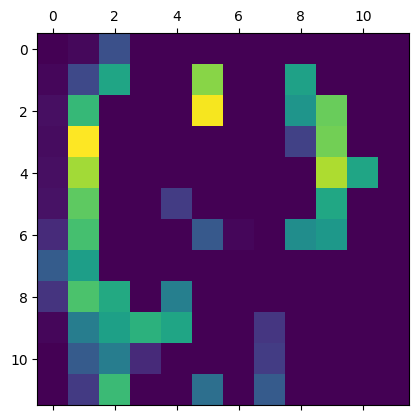

In [169]:
plt.matshow(heatmap)
plt.show()

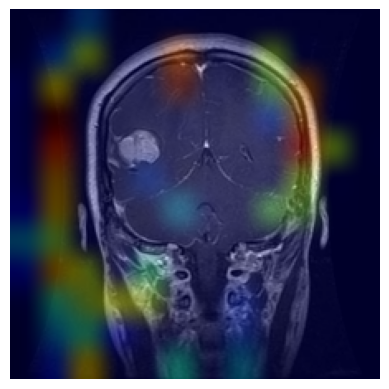

In [170]:
save_and_display_gradcam(img, heatmap)

## Plot grid of grad-cam plots from random selection of raw testing data

In [ ]:
IMG_SIZE = (224, 224)
#plt.figure(figsize=(30, 30))
#plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
num_cat = 2
num_rep = 20
#fig, axs = plt.subplots(num_rep, num_cat, sharex=True)
for j in np.arange(num_cat):
    #print(f"j: {j}")
    class_name = ["glioma", "meningioma", "notumor", "pituitary"][j]
    #print(f"class_name: {class_name}")
    for i in np.arange(num_rep):
        img = get_random_external_val_img(class_name=class_name, rand_seed = None, display=False)
        img_array = preprocess_image(img)
        binary_model = tf.keras.models.load_model("saved_models/binary_model2.keras")
        inputs = tf.keras.Input(shape=(224, 224, 1))
        outputs = binary_model(inputs)
        binary_model.predict(img_array)
        heatmap = make_gradcam_heatmap(img_array, binary_model, last_conv_layer_name)
        #plt.sca(axs[i, j])
        save_and_display_gradcam(img, heatmap, alpha=1)
        plt.show()
#plt.show()

## XAI for transfer model

In [20]:
IMG_SIZE = (224, 224)
img = get_random_external_val_img(class_name="glioma", rand_seed = 4, display=False)
img_array = preprocess_image(img, scale=True, rgb=True)

In [21]:
img_array.shape

(1, 224, 224, 3)

In [22]:
binary_transfer_model = tf.keras.models.load_model("saved_models/brain_tumor_model_binary_transferlearning.keras")
inputs = tf.keras.Input(shape=(224, 224, 3))
outputs = binary_transfer_model(inputs)


In [23]:
binary_transfer_model.predict(img_array)
binary_transfer_model.layers

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


[<Functional name=efficientnetb0, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [24]:
binary_transfer_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,295,720 (16.39 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 164,100 (641.02 KB)

In [42]:
# model is long
# binary_transfer_model.get_layer('efficientnetb0').summary()

In [26]:
binary_transfer_model.get_layer('efficientnetb0').get_layer('top_conv')

<Conv2D name=top_conv, built=True>

In [35]:
last_conv_layer_name = "efficientnetb0"

In [36]:
binary_transfer_model.layers[-1].activation = None
preds = binary_transfer_model.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


In [40]:
heatmap = make_gradcam_heatmap(img_array, binary_transfer_model, last_conv_layer_name)

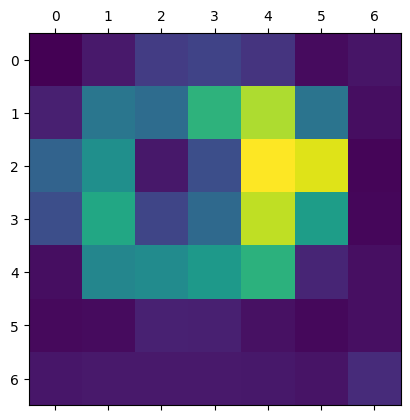

In [43]:
plt.matshow(heatmap)
plt.show()

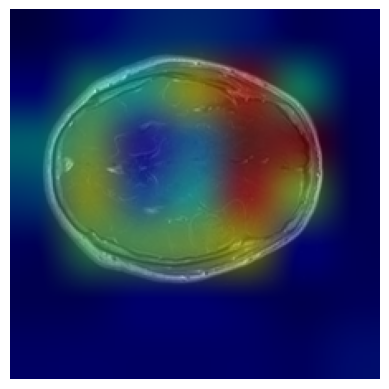

In [44]:
save_and_display_gradcam(img, heatmap)

raw_data/final_brain_tumor_preprocessed_dataset/test/glioma/test_Ishans24_001525_0b9a49f01f79c5806bcd0f4799ba2436.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


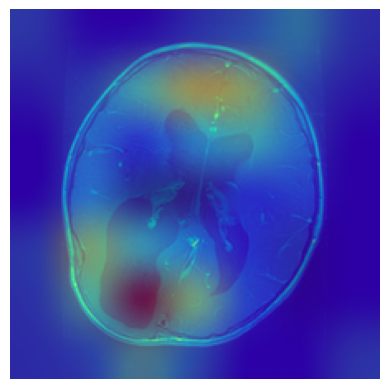

raw_data/final_brain_tumor_preprocessed_dataset/test/glioma/test_Ishans24_001454_03843f62c5840ea7ee0b66d1b31c0a67.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


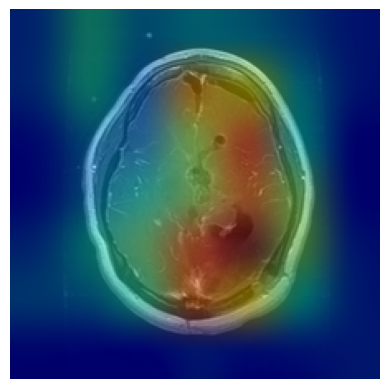

raw_data/final_brain_tumor_preprocessed_dataset/test/glioma/test_Ishans24_000995_22e44c0793794cf5becf3298f80f2bde.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


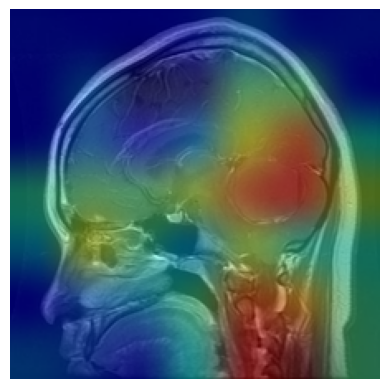

raw_data/final_brain_tumor_preprocessed_dataset/test/glioma/test_Masoud_000203_cad13416839847b0ebf97b9fe362d162.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


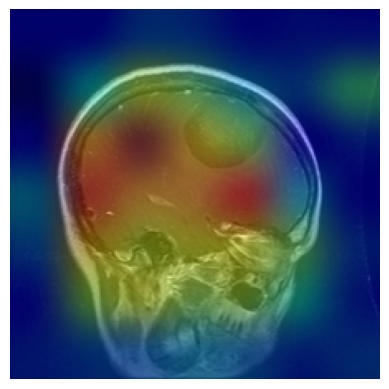

raw_data/final_brain_tumor_preprocessed_dataset/test/glioma/test_Ishans24_001291_d4ea1eebec1103941cc1983e5316752d.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


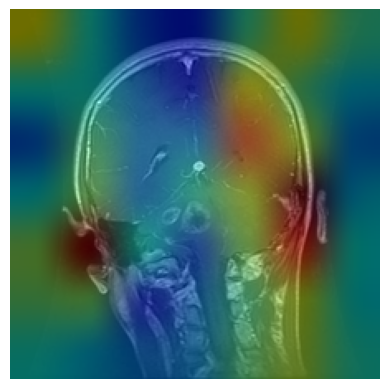

raw_data/final_brain_tumor_preprocessed_dataset/test/meningioma/test_Ishans24_000614_479819903887e654f33b622953f70bf6.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


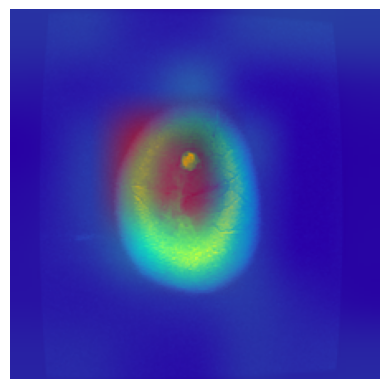

raw_data/final_brain_tumor_preprocessed_dataset/test/meningioma/test_Ishans24_001141_a83d01e84ef323737ee9c59d6d29c388.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


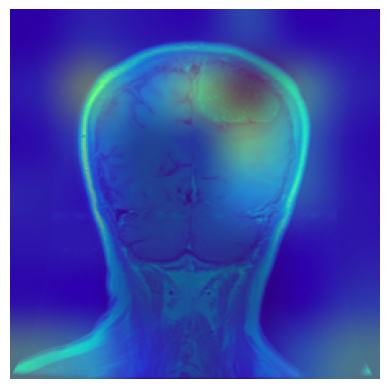

raw_data/final_brain_tumor_preprocessed_dataset/test/meningioma/test_Ishans24_001361_3134ae14cae105fac7b23981c86d00e4.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


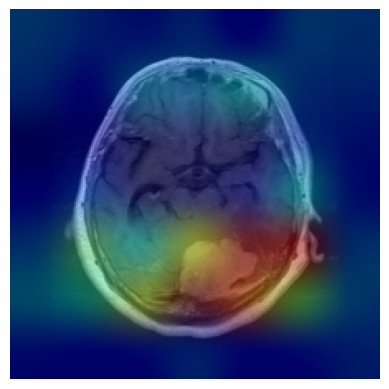

raw_data/final_brain_tumor_preprocessed_dataset/test/meningioma/test_Masoud_000906_e3efd9791d7148e4974917bc6bd103b2.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


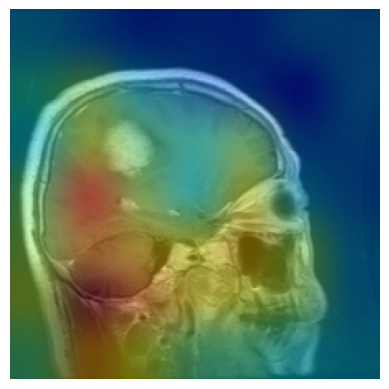

raw_data/final_brain_tumor_preprocessed_dataset/test/meningioma/test_Masoud_001443_14ac7a7df364bb3693cbd039583fc43b.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


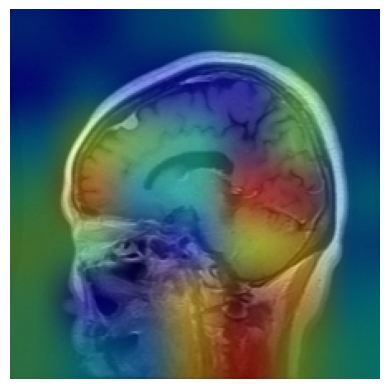

raw_data/final_brain_tumor_preprocessed_dataset/test/notumor/test_Masoud_000433_b09b0e64f42dc7bf0aa0dca7600d2fd4.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


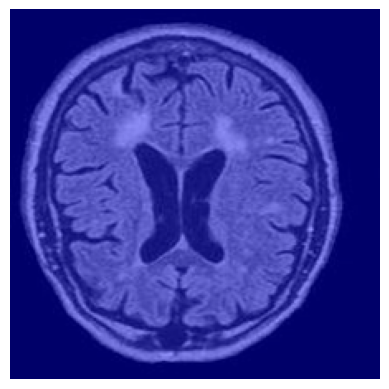

raw_data/final_brain_tumor_preprocessed_dataset/test/notumor/test_Masoud_000969_65ce6727c86b3e60b6dd69f0d4c8c4f8.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


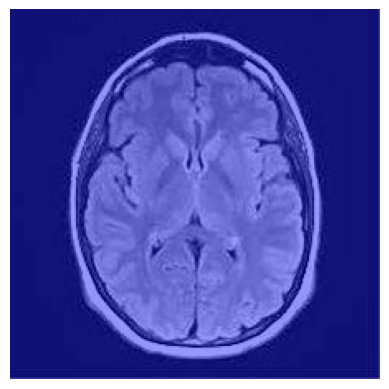

raw_data/final_brain_tumor_preprocessed_dataset/test/notumor/test_Masoud_001381_57d4354bf329c8ef61c4fa4fe17814b3.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


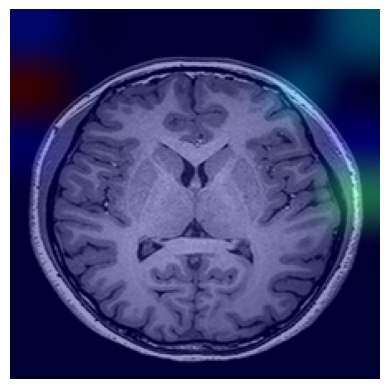

raw_data/final_brain_tumor_preprocessed_dataset/test/notumor/test_Masoud_000746_2e2ede527ec1939d5fd5a923a69c3a86.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


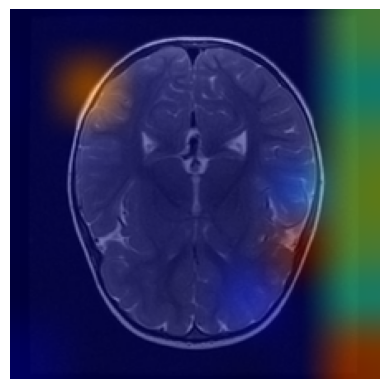

raw_data/final_brain_tumor_preprocessed_dataset/test/notumor/test_Masoud_000952_36f8ad2ba2f206b1bd86251c1b741709.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


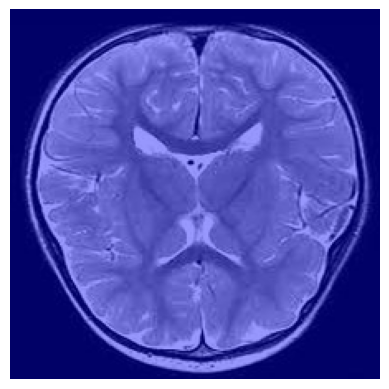

raw_data/final_brain_tumor_preprocessed_dataset/test/pituitary/test_Masoud_001176_7b219d25201f4f88788f783a5d69bb8c.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


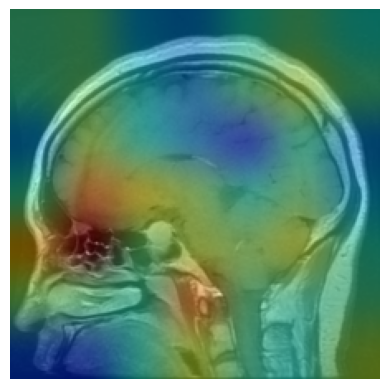

raw_data/final_brain_tumor_preprocessed_dataset/test/pituitary/test_Masoud_000743_5a4398758042be63ca64d505cfae7fbb.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


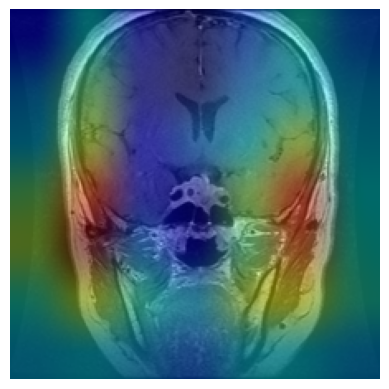

raw_data/final_brain_tumor_preprocessed_dataset/test/pituitary/test_Masoud_000178_85a2e5d07fa67931a79b412c39b5e05d.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


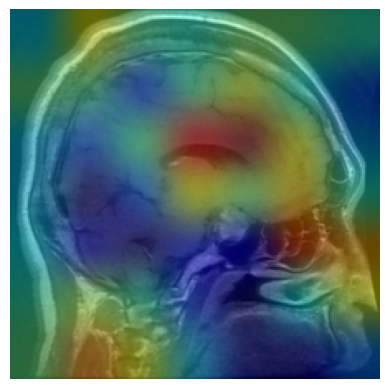

raw_data/final_brain_tumor_preprocessed_dataset/test/pituitary/test_Masoud_000450_1983660602388e9f1c38bfadb88c806f.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


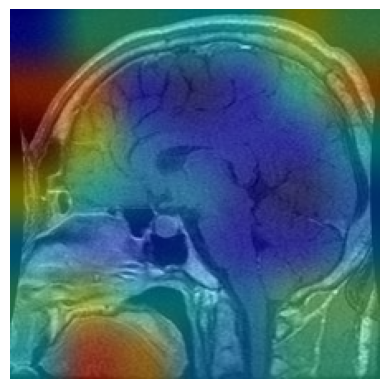

raw_data/final_brain_tumor_preprocessed_dataset/test/pituitary/test_Masoud_000018_56a6982dfd8dcc945b2f3bb7556cf40d.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


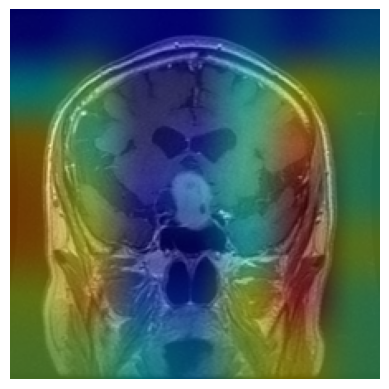

In [51]:
IMG_SIZE = (224, 224)
#plt.figure(figsize=(30, 30))
#plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
num_cat = 4
num_rep = 5
binary_transfer_model = tf.keras.models.load_model("saved_models/brain_tumor_model_binary_transferlearning.keras")
last_conv_layer_name = "efficientnetb0"
#fig, axs = plt.subplots(num_rep, num_cat, sharex=True)
for j in np.arange(num_cat):
    #print(f"j: {j}")
    class_name = ["glioma", "meningioma", "notumor", "pituitary"][j]
    #print(f"class_name: {class_name}")
    for i in np.arange(num_rep):
        img, file_path = get_random_external_test_img(class_name=class_name, rand_seed = None, display=False)
        print(file_path)
        img_array = preprocess_image(img, scale=True, rgb=True)
        inputs = tf.keras.Input(shape=(224, 224, 3))
        outputs = binary_transfer_model(inputs)
        binary_transfer_model.predict(img_array)
        heatmap = make_gradcam_heatmap(img_array, binary_transfer_model, last_conv_layer_name)
        #plt.sca(axs[i, j])
        save_and_display_gradcam(img, heatmap, alpha=0.4)
        plt.show()
#plt.show()